# Clustering Clearly
### How to use clustering/unsupervised learning in Scikit-Learn

Clustering is one of those things I've heard but never really done... so let's see how we can make it work!

In [2]:
import sklearn
import matplotlib.pyplot as plt
import numpy as np

We will be using the half-moon dataset!

In [14]:
X, y = sklearn.datasets.make_moons(n_samples=(300, 700), noise=0.1)

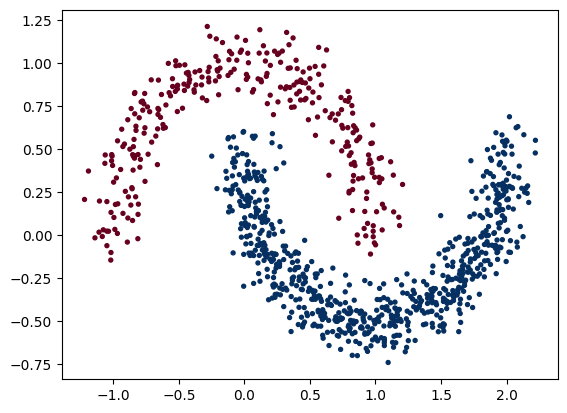

In [21]:
plt.scatter(X[:, 0], X[:, 1], s=8, c=y, cmap="RdBu")

### K-Means clustering
The simplest clustering algorithm. A very important hyperparameter is `n_clusters` - so we have to tune that! However we know there's only two clusters in the dataset in our case :D

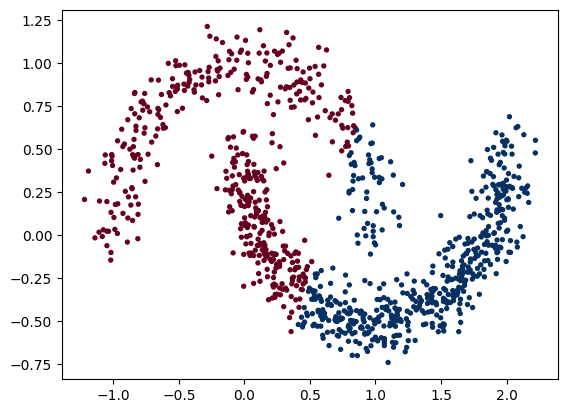

In [26]:
alg = sklearn.cluster.KMeans(n_clusters=2)
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="RdBu")

And it doesnt do so well... because it's distance based. The 'intersecting' parts will mess up the algorithm.

### DBSCAN
From the quite helpful explanation at https://builtin.com/articles/dbscan, here's my understanding of DBSCAN:  

DBSCAN is quite similar to KNN except that it doesn't just grab the 'closest neighbor'. Instead, what it does is that there is a threshold 'minimum distance', where points nearby are considered neighbours. During the clustering process, it will then include these 'neighbours' in the cluster, just like K-Means.

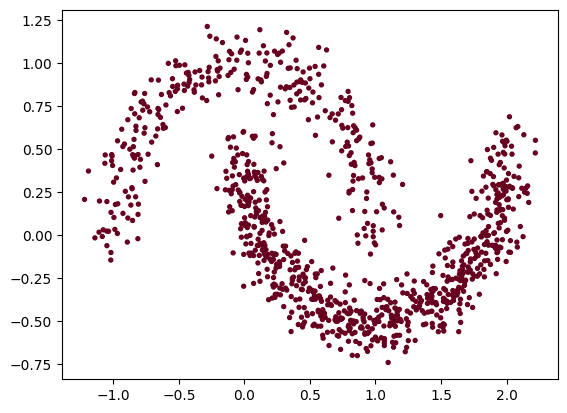

In [44]:
alg = sklearn.cluster.DBSCAN()
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="RdBu")

Oops. As you can see, DBSCAN also has very strict hyperparamter tuning. `eps` is the minimum distacne, which is important to tune!

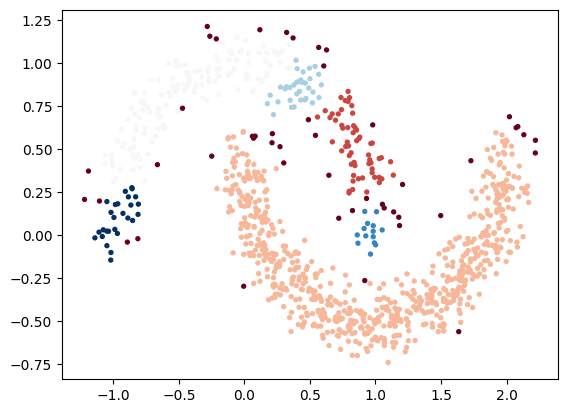

In [47]:
alg = sklearn.cluster.DBSCAN(eps=0.1, min_samples=7)
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="RdBu")

The tuning is difficult. Thankfully, a more advanced variant, HDBSCAN, is able to automatically calculate thie value. However, it does run slower.

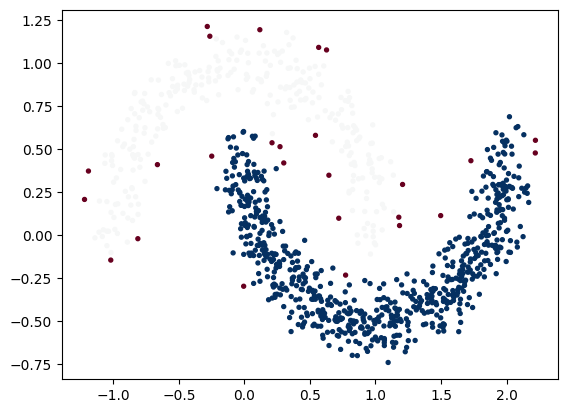

In [56]:
alg = sklearn.cluster.HDBSCAN(min_samples=7)
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="RdBu")

As you can see, it's a lot better.  

One more upside that hasn't been mentioned is that DBSCAN also works to remove outliers! The sparsely dotted points on the diagram are considered outliers. Let's remove them and visualise it.

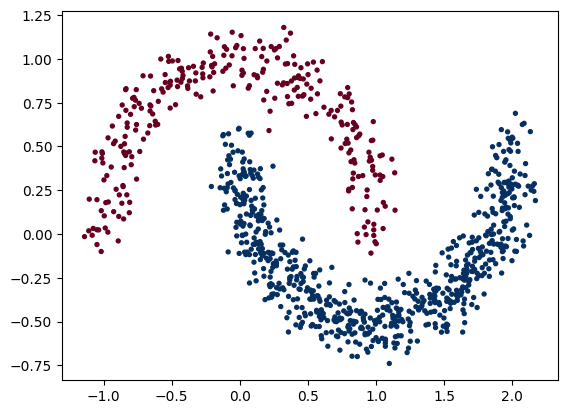

In [57]:
X_filtered = X[y_pred != -1]
y_pred_filtered = y_pred[y_pred != -1]
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], s=8, c=y_pred_filtered, cmap="RdBu")

Tada! By right, we could calculate classification accuracy since we have the true y labels. However, normally we can't do that.

In [62]:
print(sklearn.metrics.classification_report(y, y_pred, zero_division=np.nan)) # zero_division ignores error as we have no true samples for -1 

              precision    recall  f1-score   support

          -1       0.00       nan      0.00         0
           0       1.00      0.95      0.97       300
           1       1.00      0.98      0.99       700

    accuracy                           0.97      1000
   macro avg       0.67      0.97      0.65      1000
weighted avg       1.00      0.97      0.99      1000



100% precision! But some of the samples were missed and classified as outliers... close enough though :P

### Hierarchical Clustering

Hierarchical clustering is a method of clustering where you either start with a single cluster and repeatedly divide into smaller clusters (Divisive Clustering) or start with all points as their own cluster and start merging (Agglomerative Clustering). In scikit-learn, only agglomerative clustering is implemented.

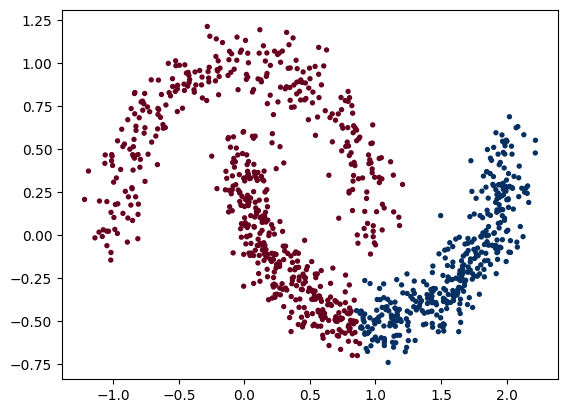

In [63]:
alg = sklearn.cluster.AgglomerativeClustering(n_clusters=2)
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="RdBu")

This doesn't look too good. Fortunately, it also has a crucial hyperparameter to tune - namely, the `linkage` hyperparameter, or how it chooses to merge the clusters.

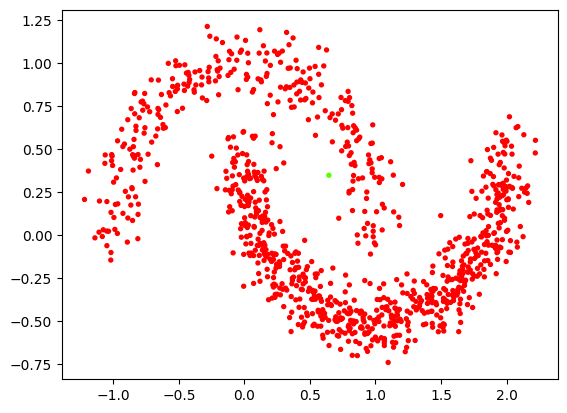

In [70]:
alg = sklearn.cluster.AgglomerativeClustering(n_clusters=2, linkage='single')
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="prism")

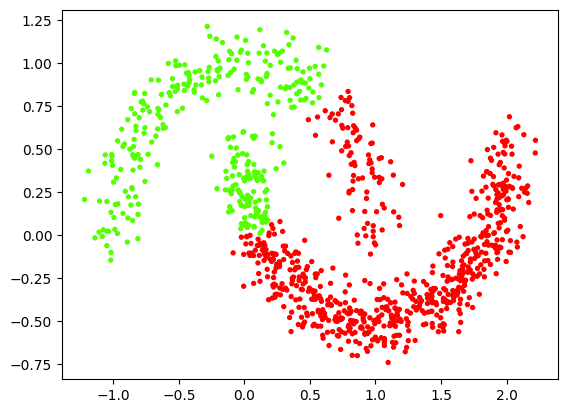

In [67]:
alg = sklearn.cluster.AgglomerativeClustering(n_clusters=2, linkage='complete')
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="prism")

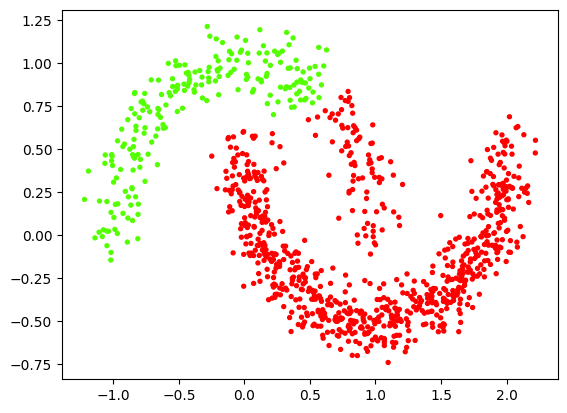

In [68]:
alg = sklearn.cluster.AgglomerativeClustering(n_clusters=2, linkage='average')
y_pred = alg.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=8, c=y_pred, cmap="prism")

Not much luck with those, however.

For further reference, scikit-learn has a list of comparions on when to use what algorithm at https://scikit-learn.org/stable/modules/clustering.html.